<a href="https://colab.research.google.com/github/mahepMSFT/Python/blob/master/INNHotelsGroup_of_New_data_%26_Past_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Colab notebook is opened successfully")

Colab notebook is opened successfully


In [3]:
# Installing the libraries with the specified version.
!pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 statsmodels==0.14.5 -q --user

In [5]:
# libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# removing the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# setting the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 2 decimal points
pd.set_option("display.float_format", lambda x: "%.2f" % x)

# library to split data
from sklearn.model_selection import train_test_split

# library to build AI model
from sklearn.tree import DecisionTreeClassifier

# library to tune AI model
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# libraries to evaluate the AI model
from sklearn.metrics import f1_score, make_scorer

# libraries to deploy the AI model
import os
import joblib

In [8]:
# defining the location where the data is stored
path = "INNHotelsGroup_pastdata.csv"
# loading the data into a Pandas dataframe
hotel = pd.read_csv(path)

In [9]:
hotel.sample(10, random_state=42)

,booking_id,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status,rebooked
26146,INNHG_127180,193,Offline,0,120.00,2,1,2022-06-20,0,2,Canceled,Yes
21329,INNHG_122363,34,Online,0,126.90,2,2,2022-05-01,0,1,Canceled,No
15293,INNHG_116327,9,Online,1,81.00,2,0,2022-02-17,0,1,Not Canceled,NaN
14834,INNHG_115868,4,Online,0,65.33,1,0,2022-02-09,0,3,Not Canceled,NaN
4890,INNHG_105924,320,Offline,1,115.00,2,0,2021-04-18,0,2,Canceled,No
24126,INNHG_125160,13,Online,1,149.33,2,1,2022-06-03,0,2,Not Canceled,NaN
18254,INNHG_119288,40,Online,1,139.87,3,2,2022-03-27,0,1,Canceled,No
20502,INNHG_121536,169,Offline,0,63.50,1,2,2022-04-22,0,2,Not Canceled,NaN
3843,INNHG_104877,180,Offline,2,100.08,2,1,2021-03-28,0,2,Canceled,Yes
8856,INNHG_109890,26,Online,3,124.00,2,2,2021-09-12,0,1,Not Canceled,NaN


In [10]:
# defining the location where the data is stored
path = "INNHotelsGroup_newdata.csv"
# loading the data into a Pandas dataframe
hotel = pd.read_csv(path)

In [11]:
hotel.sample(10, random_state=42)

,booking_id,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status
1407,INNHG_129534,142,Online,1,186.30,2,0,2022-08-03,1,3,Not Canceled
411,INNHG_128538,98,Online,1,114.30,2,0,2022-07-07,0,1,Canceled
802,INNHG_128929,140,Online,0,114.33,2,1,2022-07-18,0,3,Not Canceled
3033,INNHG_131160,35,Offline,0,85.50,2,1,2022-09-17,0,1,Not Canceled
1546,INNHG_129673,192,Online,0,99.45,2,1,2022-08-04,0,3,Canceled
554,INNHG_128681,134,Online,2,89.85,2,0,2022-07-12,0,4,Not Canceled
810,INNHG_128937,29,Online,1,144.55,2,1,2022-07-18,0,3,Not Canceled
3168,INNHG_131295,76,Offline,0,102.68,2,2,2022-09-18,0,0,Canceled
1068,INNHG_129195,190,Online,1,99.95,2,2,2022-07-24,1,2,Not Canceled
270,INNHG_128397,104,Online,1,83.12,2,0,2022-07-06,0,4,Not Canceled


In [12]:
# creating a copy of the data to avoid any changes to original data
data = hotel.copy()

In [13]:
# checking the statistical summary of the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,3583.00,92.92,73.54,0.00,28.00,81.00,146.00,346.00
no_of_special_requests,3583.00,0.84,0.84,0.00,0.00,1.00,1.00,5.00
avg_price_per_room,3583.00,121.61,36.90,0.00,96.05,118.65,143.00,300.00
no_of_adults,3583.00,2.00,0.53,0.00,2.00,2.00,2.00,4.00
no_of_weekend_nights,3583.00,0.97,0.91,0.00,0.00,1.00,2.00,7.00
required_car_parking_space,3583.00,0.06,0.23,0.00,0.00,0.00,0.00,1.00
no_of_week_nights,3583.00,2.31,1.58,0.00,1.00,2.00,3.00,17.00


In [14]:
data.arrival_date.describe()

,arrival_date
count,3583
unique,51
top,2022-07-01
freq,111


In [15]:
# defining a function to create a bar graph with percentage values

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=15,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    # increase the size of x-axis and y-axis scales
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)

    # setting axis labels
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=15)
    ax.set_ylabel('')

    # show the plot
    plt.show()

In [16]:
# defining a function to create a bar graph with percentage values

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=15,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    # increase the size of x-axis and y-axis scales
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)

    # setting axis labels
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=15)
    ax.set_ylabel('')

    # show the plot
    plt.show()

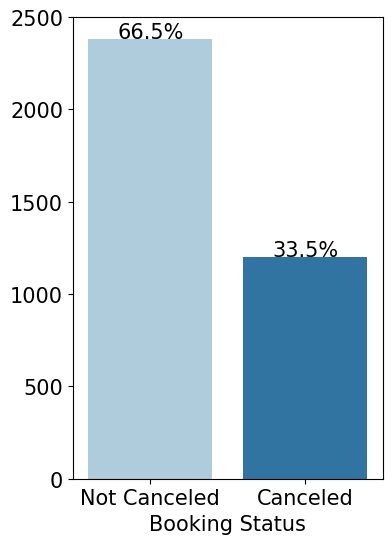

In [17]:
# visualizing the number of cancelled bookings
labeled_barplot(data, "booking_status", perc=True)

In [20]:
# visualizing the number of cancelled bookings that were rebooked
labeled_barplot(data[data.booking_status == 'Canceled'], "rebooked", perc=True)

KeyError: 'rebooked'

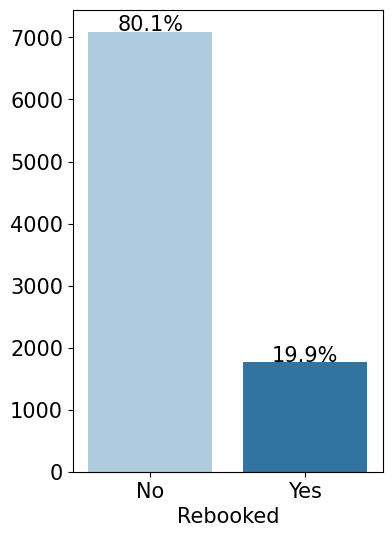

In [27]:
# visualizing the number of cancelled bookings that were rebooked
labeled_barplot(data[data.booking_status == 'Canceled'], "rebooked", perc=True)

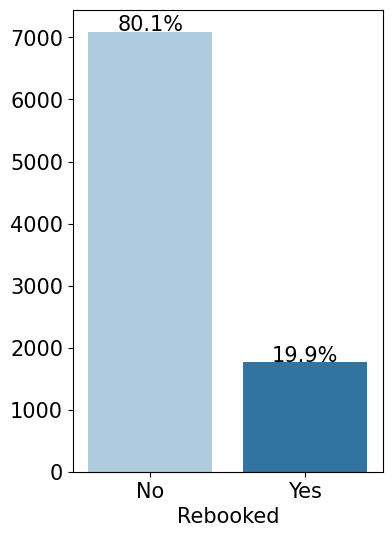

In [28]:
# visualizing the number of cancelled bookings that were rebooked
labeled_barplot(data[data.booking_status == 'Canceled'], "rebooked", perc=True)

In [22]:
path = "INNHotelsGroup_pastdata.csv"
hotel = pd.read_csv(path)
data = hotel.copy()
print("INNHotelsGroup_pastdata.csv loaded into 'data' DataFrame successfully.")

INNHotelsGroup_pastdata.csv loaded into 'data' DataFrame successfully.


In [23]:
data.sample(5, random_state=42)

,booking_id,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status,rebooked
26146,INNHG_127180,193,Offline,0,120.00,2,1,2022-06-20,0,2,Canceled,Yes
21329,INNHG_122363,34,Online,0,126.90,2,2,2022-05-01,0,1,Canceled,No
15293,INNHG_116327,9,Online,1,81.00,2,0,2022-02-17,0,1,Not Canceled,NaN
14834,INNHG_115868,4,Online,0,65.33,1,0,2022-02-09,0,3,Not Canceled,NaN
4890,INNHG_105924,320,Offline,1,115.00,2,0,2021-04-18,0,2,Canceled,No


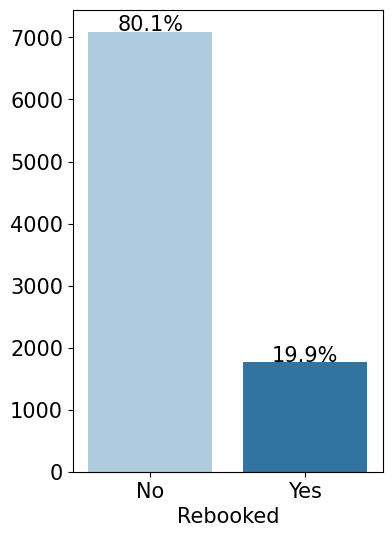

In [24]:
# visualizing the number of cancelled bookings that were rebooked
labeled_barplot(data[data.booking_status == 'Canceled'], "rebooked", perc=True)

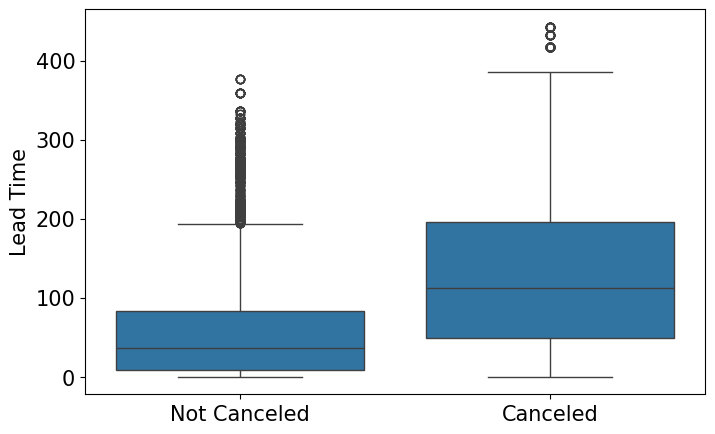

In [25]:
# visualizing the relationship between lead time and booking cancellation
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="booking_status", y="lead_time")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('')
plt.ylabel('Lead Time', fontsize=15);

In [33]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart.

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    if count > 100:
        print("The number of categories for the predictor is very high. Consider another visualization technique.")
    else:
        stack = pd.crosstab(data[predictor], data[target], normalize='index') * 100
        stack.plot(kind='bar', stacked=True, figsize=(count + 2, 6))
        plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
        plt.ylabel('Percentage')
        plt.title(f'{target} distribution across {predictor}')
        plt.xlabel(predictor.replace('_', ' ').title(), fontsize=15)
        plt.tick_params(axis='x', labelsize=15, rotation=0)
        plt.show()

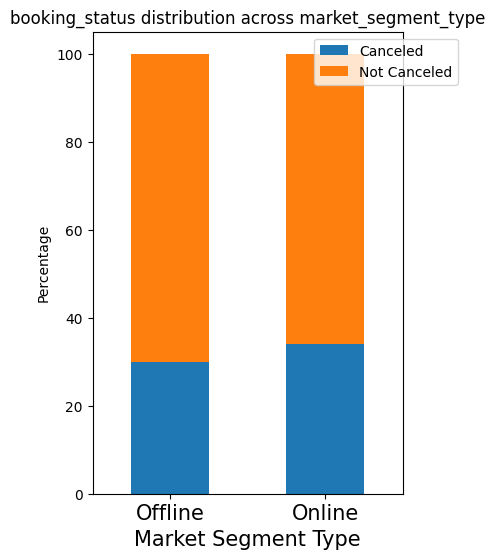

In [34]:
stacked_barplot(data, "market_segment_type", "booking_status")

In [35]:
# converting the 'arrival_date' column to datetime type
data['arrival_date'] = pd.to_datetime(data['arrival_date'])

# extracting month from 'arrival_date'
data['arrival_month'] = data['arrival_date'].dt.month

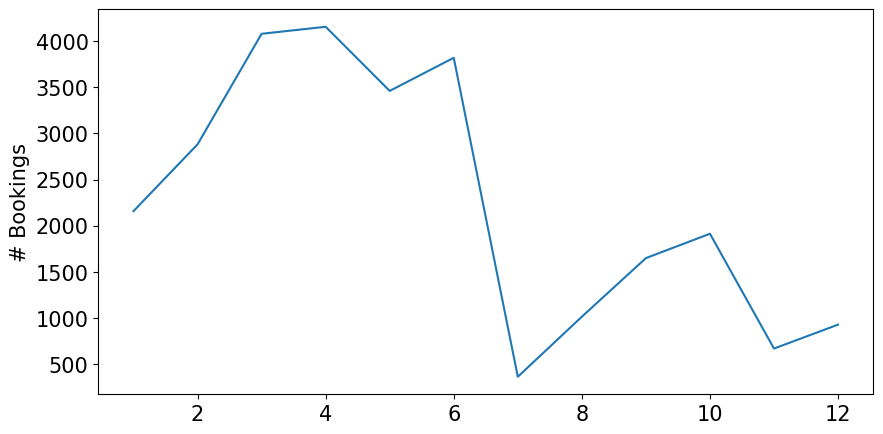

In [36]:
# grouping the data on arrival months and extracting the count of bookings
monthly_data = data.groupby(["arrival_month"])["booking_status"].count().to_frame().reset_index()
monthly_data.columns = ['Month', 'Bookings']

# visualizing the trend of number of bookings across months
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_data, x="Month", y="Bookings")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('')
plt.ylabel('# Bookings', fontsize=15);

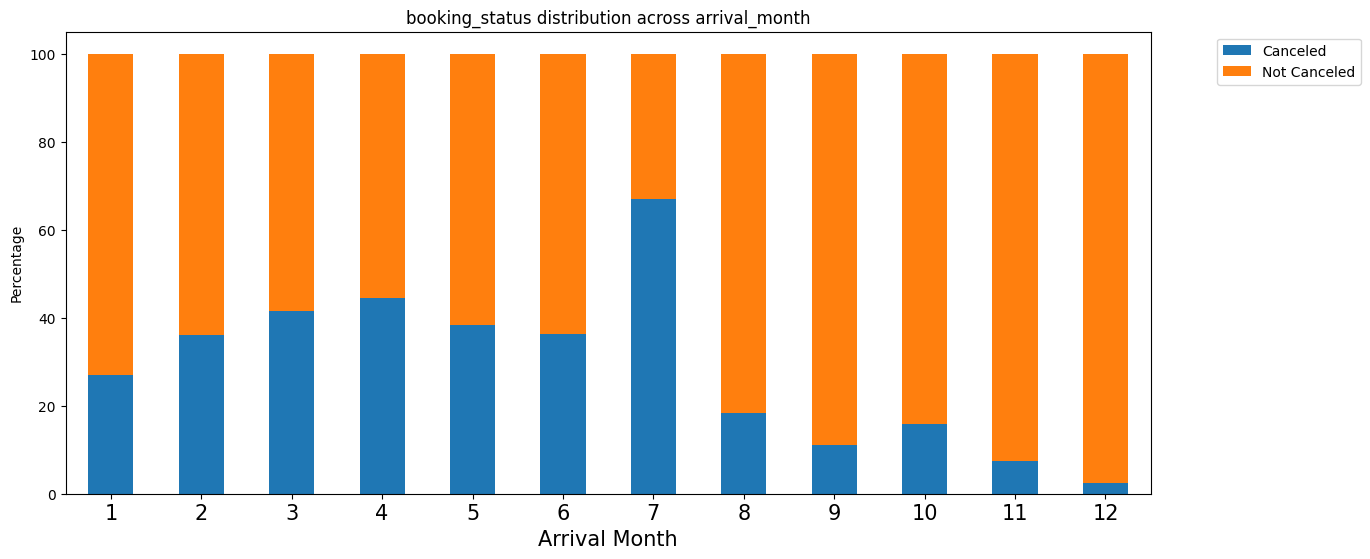

In [37]:
# visualizing the percentage of bookings canceled in each month
stacked_barplot(data, "arrival_month", "booking_status")

In [38]:
# encoding the output (also called target) attribute
data["booking_status"] = data["booking_status"].apply(
    lambda x: 1 if x == "Canceled" else 0
)

In [39]:
# separating the input and output variables
X = data.drop(["booking_status","booking_id","arrival_date","rebooked"], axis=1)
y = data["booking_status"]

# encoding the categorical input variables
X = pd.get_dummies(X, drop_first=True)

# splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

### 1. Encoding the target variable

In [ ]:
data["booking_status"] = data["booking_status"].apply(
    lambda x: 1 if x == "Canceled" else 0
)
print("Booking status encoded. Sample values:")
display(data["booking_status"].sample(5, random_state=42))

### 2. Separating input and output variables, and encoding categorical features

In [ ]:
# separating the input and output variables
X = data.drop(["booking_status","booking_id","arrival_date","rebooked"], axis=1)
y = data["booking_status"]

# encoding the categorical input variables
X = pd.get_dummies(X, drop_first=True)

print("Input features (X) after one-hot encoding. First 5 rows:")
display(X.head())

In [40]:
from sklearn.ensemble import RandomForestClassifier

# defining the AI model to build
model = RandomForestClassifier(class_weight="balanced", random_state=1)

# training the AI model on the train data
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=1)

In [41]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

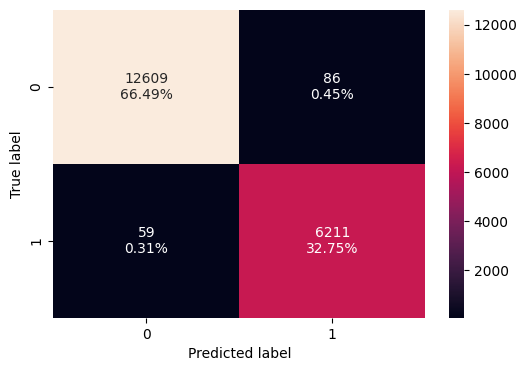

In [42]:
# confusion matrix for train data
confusion_matrix_sklearn(model, X_train, y_train)

In [43]:
# evaluating the model performance on the train data
model_train_predictions = model.predict(X_train)
model_train_score = f1_score(y_train, model_train_predictions)

print("Model Score on Train Data:", np.round(100*model_train_score, 2))

Model Score on Train Data: 98.85


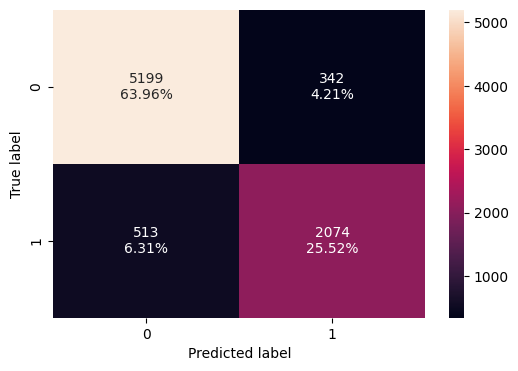

In [44]:
# confusion matrix for test data
confusion_matrix_sklearn(model, X_test, y_test)

In [45]:
# evaluating the model performance on the test data
model_test_predictions = model.predict(X_test)
model_test_score = f1_score(y_test, model_test_predictions)

print("Model Score on Test Data:", np.round(100*model_test_score, 2))

Model Score on Test Data: 82.91


In [50]:
# choosing the type of AI model
dummy_model = RandomForestClassifier(class_weight='balanced', random_state=1)

# defining the grid of parameters of the AI model to choose from
parameters = {
    'max_depth': [3,4,5,6],
    'min_samples_leaf': np.arange(5,25,5),
    'max_features': [0.6,0.7,0.8],
    'n_estimators': np.arange(50,250,50)
}

# defining the model score on which we want to compare parameter combinations
scorer = make_scorer(f1_score)

# running the model tuning algorithm
grid_obj = GridSearchCV(dummy_model, parameters, scoring=scorer, cv=5, n_jobs=-2)
grid_obj = grid_obj.fit(X_train, y_train)